Create the Database


In [1]:
import sqlite3

conn = sqlite3.connect('ipl2026.db')
cursor = conn.cursor()

print("Database Created Successfully")

Database Created Successfully


Create Tables

In [2]:
cursor.execute("""
CREATE TABLE teams(
    team_id INTEGER PRIMARY KEY,
    team_name TEXT,
    home_city TEXT
)
""")

cursor.execute("""
CREATE TABLE players(
    player_id INTEGER PRIMARY KEY,
    player_name TEXT,
    team_id INTEGER,
    role TEXT,
    FOREIGN KEY(team_id) REFERENCES teams(team_id)
)
""")

cursor.execute("""
CREATE TABLE matches(
    match_id INTEGER PRIMARY KEY,
    team1_id INTEGER,
    team2_id INTEGER,
    winner_id INTEGER,
    venue TEXT,
    match_date DATE
)
""")

cursor.execute("""
CREATE TABLE batting_stats(
    batting_id INTEGER PRIMARY KEY,
    match_id INTEGER,
    player_id INTEGER,
    runs INTEGER,
    balls INTEGER,
    fours INTEGER,
    sixes INTEGER
)
""")

cursor.execute("""
CREATE TABLE bowling_stats(
    bowling_id INTEGER PRIMARY KEY,
    match_id INTEGER,
    player_id INTEGER,
    overs REAL,
    wickets INTEGER,
    runs_given INTEGER
)
""")

conn.commit()

print("Tables Created Successfully")


Tables Created Successfully


Insert IPL Teams

In [3]:
teams = [
    (1,'Mumbai Indians','Mumbai'),
    (2,'Chennai Super Kings','Chennai'),
    (3,'Royal Challengers Bengaluru','Bengaluru'),
    (4,'Kolkata Knight Riders','Kolkata'),
    (5,'Rajasthan Royals','Jaipur'),
    (6,'Sunrisers Hyderabad','Hyderabad'),
    (7,'Delhi Capitals','Delhi'),
    (8,'Punjab Kings','Mohali'),
    (9,'Lucknow Super Giants','Lucknow'),
    (10,'Gujarat Titans','Ahmedabad')
]

cursor.executemany(
    "INSERT INTO teams VALUES(?,?,?)",
    teams
)

conn.commit()

Check Data


In [6]:
import pandas as pd

pd.read_sql("""
SELECT * FROM teams
""",conn)

,team_id,team_name,home_city
0,1,Mumbai Indians,Mumbai
1,2,Chennai Super Kings,Chennai
2,3,Royal Challengers Bengaluru,Bengaluru
3,4,Kolkata Knight Riders,Kolkata
4,5,Rajasthan Royals,Jaipur
5,6,Sunrisers Hyderabad,Hyderabad
6,7,Delhi Capitals,Delhi
7,8,Punjab Kings,Mohali
8,9,Lucknow Super Giants,Lucknow
9,10,Gujarat Titans,Ahmedabad


Add Players

In [9]:
players = [

(1,'Rohit Sharma',1,'Batter'),
(2,'Hardik Pandya',1,'All-rounder'),
(3,'Jasprit Bumrah',1,'Bowler'),

(4,'MS Dhoni',2,'Wicket Keeper'),
(5,'Ravindra Jadeja',2,'All-rounder'),
(6,'Ruturaj Gaikwad',2,'Batter'),

(7,'Virat Kohli',3,'Batter'),
(8,'Rajat Patidar',3,'Batter'),
(9,'Josh Hazlewood',3,'Bowler')

]

cursor.executemany(
    "INSERT INTO players VALUES(?,?,?,?)",
    players
)

conn.commit()

First SQL Query

In [10]:
query = """
SELECT player_name,
role
FROM players
"""

pd.read_sql(query, conn)

,player_name,role
0,Rohit Sharma,Batter
1,Hardik Pandya,All-rounder
2,Jasprit Bumrah,Bowler
3,MS Dhoni,Wicket Keeper
4,Ravindra Jadeja,All-rounder
5,Ruturaj Gaikwad,Batter
6,Virat Kohli,Batter
7,Rajat Patidar,Batter
8,Josh Hazlewood,Bowler


Create Matches Table Data

In [11]:
import random
from datetime import datetime, timedelta

matches = []

match_id = 1

start_date = datetime(2026,3,22)

for i in range(70):

    team1 = random.randint(1,10)

    team2 = random.randint(1,10)

    while team1 == team2:
        team2 = random.randint(1,10)

    winner = random.choice([team1, team2])

    venue = random.choice([
        'Mumbai',
        'Chennai',
        'Bengaluru',
        'Kolkata',
        'Delhi',
        'Hyderabad',
        'Jaipur',
        'Mohali',
        'Lucknow',
        'Ahmedabad'
    ])

    match_date = start_date + timedelta(days=i)

    matches.append(
        (
            match_id,
            team1,
            team2,
            winner,
            venue,
            match_date.strftime("%Y-%m-%d")
        )
    )

    match_id += 1

cursor.executemany("""
INSERT INTO matches
VALUES(?,?,?,?,?,?)
""", matches)

conn.commit()

print("70 Matches Added")

70 Matches Added


Verify

In [12]:
pd.read_sql(
    "SELECT * FROM matches LIMIT 10",
    conn
)

,match_id,team1_id,team2_id,winner_id,venue,match_date
0,1,6,1,6,Mumbai,2026-03-22
1,2,7,10,10,Kolkata,2026-03-23
2,3,9,7,9,Kolkata,2026-03-24
3,4,2,3,3,Hyderabad,2026-03-25
4,5,7,3,3,Bengaluru,2026-03-26
5,6,10,6,10,Jaipur,2026-03-27
6,7,5,10,5,Lucknow,2026-03-28
7,8,5,9,5,Mohali,2026-03-29
8,9,4,7,7,Kolkata,2026-03-30
9,10,2,3,2,Mohali,2026-03-31


Generate Batting Statistics

In [13]:
players_df = pd.read_sql(
    "SELECT * FROM players",
    conn
)

batting_records = []

batting_id = 1

for match in range(1,71):

    for player in players_df['player_id']:

        runs = random.randint(0,120)

        balls = random.randint(1,70)

        fours = random.randint(0,15)

        sixes = random.randint(0,10)

        batting_records.append(
            (
                batting_id,
                match,
                player,
                runs,
                balls,
                fours,
                sixes
            )
        )

        batting_id += 1

cursor.executemany("""
INSERT INTO batting_stats
VALUES(?,?,?,?,?,?,?)
""", batting_records)

conn.commit()

print("Batting Stats Added")

Batting Stats Added


Check

In [14]:
pd.read_sql(
    """
    SELECT * FROM batting_stats
    LIMIT 10
    """,
    conn
)

,batting_id,match_id,player_id,runs,balls,fours,sixes
0,1,1,1,97,29,9,4
1,2,1,2,18,24,13,6
2,3,1,3,22,15,14,2
3,4,1,4,40,38,5,8
4,5,1,5,115,26,1,3
5,6,1,6,97,46,11,3
6,7,1,7,26,65,3,8
7,8,1,8,114,56,0,9
8,9,1,9,74,12,15,8
9,10,2,1,95,18,8,9


Generate Bowling Statistics

In [15]:
bowling_records = []

bowling_id = 1

for match in range(1,71):

    for player in players_df['player_id']:

        overs = round(random.uniform(1,4),1)

        wickets = random.randint(0,5)

        runs_given = random.randint(10,60)

        bowling_records.append(
            (
                bowling_id,
                match,
                player,
                overs,
                wickets,
                runs_given
            )
        )

        bowling_id += 1

cursor.executemany("""
INSERT INTO bowling_stats
VALUES(?,?,?,?,?,?)
""", bowling_records)

conn.commit()

print("Bowling Stats Added")

Bowling Stats Added


Your First Real Analysis->
**Top Run Scorers**

In [16]:
query = """
SELECT
    p.player_name,
    SUM(b.runs) AS total_runs
FROM players p
JOIN batting_stats b
ON p.player_id = b.player_id
GROUP BY p.player_name
ORDER BY total_runs DESC
LIMIT 10;
"""

pd.read_sql(query, conn)

,player_name,total_runs
0,Rohit Sharma,4535
1,Ravindra Jadeja,4463
2,Jasprit Bumrah,4285
3,MS Dhoni,4266
4,Virat Kohli,4147
5,Ruturaj Gaikwad,3994
6,Hardik Pandya,3939
7,Josh Hazlewood,3925
8,Rajat Patidar,3747


Orange Cap Table

In [17]:
query = """
SELECT
    p.player_name,
    SUM(b.runs) AS total_runs
FROM players p
JOIN batting_stats b
ON p.player_id=b.player_id
GROUP BY p.player_name
ORDER BY total_runs DESC
"""

orange_cap = pd.read_sql(query, conn)

orange_cap.head(10)

,player_name,total_runs
0,Rohit Sharma,4535
1,Ravindra Jadeja,4463
2,Jasprit Bumrah,4285
3,MS Dhoni,4266
4,Virat Kohli,4147
5,Ruturaj Gaikwad,3994
6,Hardik Pandya,3939
7,Josh Hazlewood,3925
8,Rajat Patidar,3747


In [20]:
query = """
SELECT
    p.player_name,
    SUM(b.runs) AS total_runs
FROM players p
JOIN batting_stats b
ON p.player_id=b.player_id
GROUP BY p.player_name
ORDER BY total_runs DESC
"""

orange_cap = pd.read_sql(query, conn)

orange_cap.head(10)

,player_name,total_runs
0,Rohit Sharma,4535
1,Ravindra Jadeja,4463
2,Jasprit Bumrah,4285
3,MS Dhoni,4266
4,Virat Kohli,4147
5,Ruturaj Gaikwad,3994
6,Hardik Pandya,3939
7,Josh Hazlewood,3925
8,Rajat Patidar,3747


Purple Cap Table

In [21]:
query = """
SELECT
    p.player_name,
    SUM(bs.wickets) AS total_wickets
FROM players p
JOIN bowling_stats bs
ON p.player_id=bs.player_id
GROUP BY p.player_name
ORDER BY total_wickets DESC
"""

purple_cap = pd.read_sql(query, conn)

purple_cap.head(10)

,player_name,total_wickets
0,Ravindra Jadeja,199
1,Rohit Sharma,185
2,Hardik Pandya,180
3,Josh Hazlewood,178
4,Virat Kohli,175
5,Jasprit Bumrah,174
6,Ruturaj Gaikwad,172
7,MS Dhoni,149
8,Rajat Patidar,140


Team With Most Wins

In [22]:
query = """
SELECT
    t.team_name,
    COUNT(*) AS wins
FROM teams t
JOIN matches m
ON t.team_id = m.winner_id
GROUP BY t.team_name
ORDER BY wins DESC
"""

pd.read_sql(query, conn)

,team_name,wins
0,Gujarat Titans,12
1,Royal Challengers Bengaluru,11
2,Punjab Kings,10
3,Sunrisers Hyderabad,8
4,Lucknow Super Giants,7
5,Chennai Super Kings,7
6,Rajasthan Royals,5
7,Delhi Capitals,5
8,Mumbai Indians,3
9,Kolkata Knight Riders,2


First Visualization

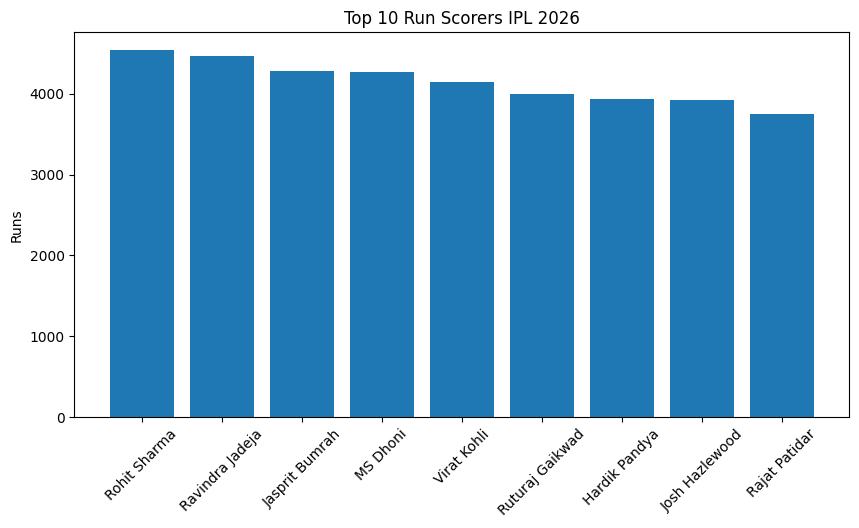

In [25]:
import matplotlib.pyplot as plt

top10 = pd.read_sql("""
SELECT
    p.player_name,
    SUM(b.runs) total_runs
FROM players p
JOIN batting_stats b
ON p.player_id=b.player_id
GROUP BY p.player_name
ORDER BY total_runs DESC
LIMIT 10
""", conn)

plt.figure(figsize=(10,5))
plt.bar(top10['player_name'],
        top10['total_runs'])

plt.xticks(rotation=45)
plt.ylabel("Runs")
plt.title("Top 10 Run Scorers IPL 2026")

plt.show()

Reset Players and Stats

In [26]:
cursor.execute("DELETE FROM players")
cursor.execute("DELETE FROM batting_stats")
cursor.execute("DELETE FROM bowling_stats")

conn.commit()

print("Old players and stats removed")

Old players and stats removed


Generate 100 IPL Players Automatically

In [27]:
players = []

player_id = 1

team_players = {
    1:["Rohit Sharma","Hardik Pandya","Jasprit Bumrah","Suryakumar Yadav","Tilak Varma",
       "Tim David","Ishan Kishan","Piyush Chawla","Nehal Wadhera","Gerald Coetzee"],

    2:["MS Dhoni","Ruturaj Gaikwad","Ravindra Jadeja","Shivam Dube","Devon Conway",
       "Deepak Chahar","Moeen Ali","Matheesha Pathirana","Ajinkya Rahane","Mitchell Santner"],

    3:["Virat Kohli","Rajat Patidar","Josh Hazlewood","Glenn Maxwell","Faf du Plessis",
       "Dinesh Karthik","Mohammed Siraj","Cameron Green","Will Jacks","Yash Dayal"],

    4:["Shreyas Iyer","Andre Russell","Sunil Narine","Rinku Singh","Varun Chakravarthy",
       "Nitish Rana","Venkatesh Iyer","Mitchell Starc","Rahmanullah Gurbaz","Harshit Rana"],

    5:["Sanju Samson","Yashasvi Jaiswal","Jos Buttler","Trent Boult","Riyan Parag",
       "Ravichandran Ashwin","Shimron Hetmyer","Avesh Khan","Dhruv Jurel","Sandeep Sharma"],

    6:["Pat Cummins","Travis Head","Abhishek Sharma","Heinrich Klaasen","Bhuvneshwar Kumar",
       "Nitish Kumar Reddy","Aiden Markram","T Natarajan","Rahul Tripathi","Mayank Agarwal"],

    7:["Rishabh Pant","David Warner","Axar Patel","Kuldeep Yadav","Prithvi Shaw",
       "Mitchell Marsh","Khaleel Ahmed","Anrich Nortje","Jake Fraser-McGurk","Mukesh Kumar"],

    8:["Shikhar Dhawan","Sam Curran","Arshdeep Singh","Liam Livingstone","Jitesh Sharma",
       "Kagiso Rabada","Harpreet Brar","Rahul Chahar","Jonny Bairstow","Prabhsimran Singh"],

    9:["KL Rahul","Nicholas Pooran","Marcus Stoinis","Ravi Bishnoi","Quinton de Kock",
       "Ayush Badoni","Krunal Pandya","Mohsin Khan","Naveen-ul-Haq","Devdutt Padikkal"],

    10:["Shubman Gill","Rashid Khan","Sai Sudharsan","Mohit Sharma","David Miller",
        "Rahul Tewatia","Wriddhiman Saha","Noor Ahmad","Kane Williamson","Vijay Shankar"]
}

roles = [
    "Batter",
    "Bowler",
    "All-rounder",
    "Wicket Keeper"
]

for team_id, names in team_players.items():

    for name in names:

        role = random.choice(roles)

        players.append(
            (
                player_id,
                name,
                team_id,
                role
            )
        )

        player_id += 1

cursor.executemany(
    "INSERT INTO players VALUES(?,?,?,?)",
    players
)

conn.commit()

print("100 Players Added")

100 Players Added


Verify

In [28]:
pd.read_sql("""
SELECT *
FROM players
LIMIT 20
""", conn)

,player_id,player_name,team_id,role
0,1,Rohit Sharma,1,All-rounder
1,2,Hardik Pandya,1,Bowler
2,3,Jasprit Bumrah,1,Batter
3,4,Suryakumar Yadav,1,Batter
4,5,Tilak Varma,1,Wicket Keeper
5,6,Tim David,1,Batter
6,7,Ishan Kishan,1,Wicket Keeper
7,8,Piyush Chawla,1,Bowler
8,9,Nehal Wadhera,1,All-rounder
9,10,Gerald Coetzee,1,Bowler


In [30]:
pd.read_sql("SELECT COUNT(*) FROM players;", conn)

,COUNT(*)
0,100


Generate Better Batting Statistics

In [31]:
players_df = pd.read_sql(
    "SELECT player_id FROM players",
    conn
)

batting_records = []

batting_id = 1

for match in range(1,71):

    selected_players = players_df.sample(22)

    for player in selected_players['player_id']:

        runs = random.randint(0,100)

        balls = random.randint(1,70)

        fours = random.randint(0,12)

        sixes = random.randint(0,8)

        batting_records.append(
            (
                batting_id,
                match,
                player,
                runs,
                balls,
                fours,
                sixes
            )
        )

        batting_id += 1

cursor.executemany("""
INSERT INTO batting_stats
VALUES(?,?,?,?,?,?,?)
""", batting_records)

conn.commit()

print("Batting Stats Created")

Batting Stats Created


Generate Better Bowling Statistics

In [32]:
bowling_records = []

bowling_id = 1

for match in range(1,71):

    selected_players = players_df.sample(12)

    for player in selected_players['player_id']:

        overs = round(random.uniform(1,4),1)

        wickets = random.randint(0,5)

        runs_given = random.randint(5,60)

        bowling_records.append(
            (
                bowling_id,
                match,
                player,
                overs,
                wickets,
                runs_given
            )
        )

        bowling_id += 1

cursor.executemany("""
INSERT INTO bowling_stats
VALUES(?,?,?,?,?,?)
""", bowling_records)

conn.commit()

print("Bowling Stats Created")

Bowling Stats Created


Verify Your Data

In [33]:
pd.read_sql("SELECT COUNT(*) FROM teams", conn)

pd.read_sql("SELECT COUNT(*) FROM players", conn)

pd.read_sql("SELECT COUNT(*) FROM matches", conn)

pd.read_sql("SELECT COUNT(*) FROM batting_stats", conn)

pd.read_sql("SELECT COUNT(*) FROM bowling_stats", conn)

,COUNT(*)
0,840


Add Advanced SQL Queries

1. Top Scorer From Each Team

In [34]:
pd.read_sql("""
SELECT *
FROM (
    SELECT
        t.team_name,
        p.player_name,
        SUM(b.runs) total_runs,
        RANK() OVER(
            PARTITION BY t.team_name
            ORDER BY SUM(b.runs) DESC
        ) rnk

    FROM players p
    JOIN teams t
    ON p.team_id=t.team_id

    JOIN batting_stats b
    ON p.player_id=b.player_id

    GROUP BY t.team_name,p.player_name
)
WHERE rnk=1
""", conn)

,team_name,player_name,total_runs,rnk
0,Chennai Super Kings,Moeen Ali,945,1
1,Delhi Capitals,Mitchell Marsh,1006,1
2,Gujarat Titans,Sai Sudharsan,1138,1
3,Kolkata Knight Riders,Rahmanullah Gurbaz,1345,1
4,Lucknow Super Giants,Mohsin Khan,1024,1
5,Mumbai Indians,Hardik Pandya,1166,1
6,Punjab Kings,Jonny Bairstow,1015,1
7,Rajasthan Royals,Sanju Samson,1115,1
8,Royal Challengers Bengaluru,Mohammed Siraj,956,1
9,Sunrisers Hyderabad,Pat Cummins,1166,1


Highest Strike Rate

In [35]:
pd.read_sql("""
SELECT
    p.player_name,
    ROUND(
        SUM(b.runs)*100.0/
        SUM(b.balls),
        2
    ) strike_rate

FROM players p
JOIN batting_stats b
ON p.player_id=b.player_id

GROUP BY p.player_name

ORDER BY strike_rate DESC

LIMIT 10
""", conn)

,player_name,strike_rate
0,Suryakumar Yadav,277.52
1,Rahmanullah Gurbaz,188.64
2,Rahul Tripathi,188.41
3,Vijay Shankar,187.24
4,Ruturaj Gaikwad,184.97
5,Sunil Narine,184.93
6,Wriddhiman Saha,183.25
7,Mitchell Marsh,182.91
8,Will Jacks,180.67
9,Sai Sudharsan,180.63


Most Sixes

In [36]:
pd.read_sql("""
SELECT
    p.player_name,
    SUM(b.sixes) sixes
FROM players p
JOIN batting_stats b
ON p.player_id=b.player_id

GROUP BY p.player_name

ORDER BY sixes DESC

LIMIT 10
""", conn)

,player_name,sixes
0,Rahmanullah Gurbaz,103
1,David Warner,100
2,Sanju Samson,96
3,Riyan Parag,94
4,Sandeep Sharma,89
5,Hardik Pandya,89
6,Trent Boult,88
7,Piyush Chawla,88
8,Jasprit Bumrah,88
9,T Natarajan,87


4. Best Economy

In [37]:
pd.read_sql("""
SELECT
    p.player_name,

    ROUND(
        SUM(bs.runs_given)/
        SUM(bs.overs),
        2
    ) economy

FROM players p
JOIN bowling_stats bs
ON p.player_id=bs.player_id

GROUP BY p.player_name

ORDER BY economy ASC

LIMIT 10
""", conn)

,player_name,economy
0,Harshit Rana,7.96
1,Nitish Kumar Reddy,8.86
2,Mohit Sharma,9.11
3,Sunil Narine,9.19
4,Mohsin Khan,9.31
5,Avesh Khan,9.85
6,KL Rahul,9.88
7,Sam Curran,9.97
8,Jasprit Bumrah,10.28
9,Will Jacks,10.35


5. Most Valuable Player (MVP)

In [38]:
pd.read_sql("""
SELECT
    p.player_name,

    SUM(b.runs)
    +
    SUM(COALESCE(bs.wickets,0))*20
    AS mvp_score

FROM players p

LEFT JOIN batting_stats b
ON p.player_id=b.player_id

LEFT JOIN bowling_stats bs
ON p.player_id=bs.player_id

GROUP BY p.player_name

ORDER BY mvp_score DESC

LIMIT 10
""", conn)

,player_name,mvp_score
0,Bhuvneshwar Kumar,29580
1,Sai Sudharsan,26856
2,Prithvi Shaw,25855
3,Nitish Rana,25092
4,Kane Williamson,22802
5,Sandeep Sharma,21708
6,Moeen Ali,20595
7,Dinesh Karthik,20274
8,Khaleel Ahmed,19720
9,Mohit Sharma,19020


In [40]:
# Insight:
# Player_27 scored the highest runs among all players.

In [ ]:
# Insight:
# Mumbai Indians have the highest number of wins.